In [21]:
import requests
import pandas as pd

def get_smiles_from_cid(cid: int):
    # versuche CanonicalSMILES, falls nicht vorhanden -> IsomericSMILES
    for prop in ["CanonicalSMILES", "IsomericSMILES", "SMILES"]:
        url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/property/{prop}/JSON"
        r = requests.get(url, timeout=20)
        if r.status_code != 200:
            continue
        js = r.json()
        props = js.get("PropertyTable", {}).get("Properties", [])
        if props and prop in props[0]:
            return props[0][prop]
    return None

def get_mp_raw_from_cid(cid: int):
    url_view = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug_view/data/compound/{cid}/JSON/?heading=Melting%20Point"
    r = requests.get(url_view, timeout=20)
    if r.status_code != 200:
        return None

    data = r.json()
    mp_values = []

    def walk(sec):
        if isinstance(sec, dict):
            if "Information" in sec:
                for info in sec["Information"]:
                    v = info.get("Value", {})
                    # häufig: StringWithMarkup
                    swm = v.get("StringWithMarkup", [])
                    if swm:
                        s = swm[0].get("String", "")
                        if s:
                            mp_values.append(s)
                    # seltener: Number
                    if "Number" in v:
                        mp_values.append(str(v["Number"]))

            for k in ("Section", "Subsection"):
                if k in sec:
                    for s2 in sec[k]:
                        walk(s2)

        elif isinstance(sec, list):
            for x in sec:
                walk(x)

    record = data.get("Record", {})
    walk(record.get("Section", []))

    return mp_values if mp_values else None

def pubchem_mp_from_cid(cid: int):
    smiles = get_smiles_from_cid(cid)
    if smiles is None:
        return None

    mp_raw = get_mp_raw_from_cid(cid)
    if mp_raw is None:
        return None

    return smiles, mp_raw

# Demo
cids = [241, 962, 702]
rows = []
for cid in cids:
    out = pubchem_mp_from_cid(cid)
    if out is None:
        print("No MP or SMILES for CID:", cid)
        continue
    smiles, mp_raw = out
    rows.append({"cid": cid, "SMILES": smiles, "Tm": mp_raw})

df = pd.DataFrame(rows)
df


,cid,SMILES,Tm
0,241,C1=CC=CC=C1,"[41.9 °F (NTP, 1992), 5.558 °C, 5.5 °C, 6Â °C,..."
1,962,O,"[32 °F, [0], 0 °C, 0 °C]"
2,702,CCO,"[-173.4 °F (NTP, 1992), [-114.1], -114.14 °C, ..."


In [22]:
import numpy as np
mp = np.array(df["Tm"])



In [23]:
import re
import numpy as np

def parse_mp_prioritized(mp_list):
    if not mp_list:
        return None

    c_vals, k_vals, f_vals = [], [], []

    for entry in mp_list:
        if not isinstance(entry, str):
            continue

        nums = re.findall(r"-?\d+\.?\d*", entry)
        if not nums:
            continue

        for n in nums:
            v = float(n)
            if "°C" in entry or " C" in entry:
                c_vals.append(v + 273.15)
            elif " K" in entry:
                k_vals.append(v)
            elif "°F" in entry or " F" in entry:
                f_vals.append((v - 32) * 5/9 + 273.15)

    # Priorität: °C > K > °F
    if c_vals:
        return np.median(c_vals)
    if k_vals:
        return np.median(k_vals)
    if f_vals:
        return np.median(f_vals)

    return None


In [24]:
df["Tm_K"] = df["Tm"].apply(parse_mp_prioritized)
df = df.dropna(subset=["Tm_K"]).reset_index(drop=True)


In [25]:
df

,cid,SMILES,Tm,Tm_K
0,241,C1=CC=CC=C1,"[41.9 °F (NTP, 1992), 5.558 °C, 5.5 °C, 6Â °C,...",278.708
1,962,O,"[32 °F, [0], 0 °C, 0 °C]",273.150
2,702,CCO,"[-173.4 °F (NTP, 1992), [-114.1], -114.14 °C, ...",159.050


In [26]:
import gzip, io, requests

URL = "https://ftp.ncbi.nlm.nih.gov/pubchem/Compound/Extras/CID-SMILES.gz"

def get_some_cids(n=5000):
    r = requests.get(URL, stream=True, timeout=60)
    r.raise_for_status()

    cids = []
    with gzip.GzipFile(fileobj=r.raw) as gz:
        for line in gz:
            # Format: CID<TAB>SMILES
            cid_str, smiles = line.decode("utf-8", errors="ignore").strip().split("\t", 1)
            cids.append(int(cid_str))
            if len(cids) >= n:
                break
    return cids

cids = get_some_cids(3000)
len(cids), cids[:10]


(3000, [1, 2, 3, 4, 5, 6, 7, 8, 9, 11])

In [27]:
from rdkit import Chem

METALS = {
    "Li","Na","K","Rb","Cs","Fr",
    "Be","Mg","Ca","Sr","Ba","Ra",
    "Fe","Cu","Zn","Ag","Au","Hg",
    "Al","Sn","Pb","Ni","Co","Mn","Cr"
}

def is_organic_smiles(smiles: str) -> bool:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False

    atoms = [a.GetSymbol() for a in mol.GetAtoms()]

    # muss Kohlenstoff enthalten
    if "C" not in atoms:
        return False

    # keine Metalle
    if any(a in METALS for a in atoms):
        return False

    # mindestens eine C–C oder C–H Bindung
    for bond in mol.GetBonds():
        a1 = bond.GetBeginAtom().GetSymbol()
        a2 = bond.GetEndAtom().GetSymbol()
        if ("C" in (a1, a2)) and (a1 == "C" or a2 == "C"):
            return True

    return False


In [28]:

rows = []
for cid in cids[2000:3000]:
    out = pubchem_mp_from_cid(cid)
    # if out is None:
    #     print("No MP or SMILES for CID:", cid)
    #     continue
    
    if out:
        smiles, mp_raw = out
        if is_organic_smiles(smiles):
            rows.append({"cid": cid, "SMILES": smiles, "Tm": mp_raw})

df = pd.DataFrame(rows)
df

,cid,SMILES,Tm
0,2145,CCC1(CCC(=O)NC1=O)C2=CC=C(C=C2)N,"[223-225, 159-150 °C, 149 - 150 °C]"
1,2148,C1=CC(=CC=C1C(=O)NCC(=O)O)N,"[199-200 °C, 198-199 °C, 198.5 °C]"
2,2153,CN1C2=C(C(=O)N(C1=O)C)NC=N2,"[522 to 525 °F (NTP, 1992), [273], 274 °C, 273..."
3,2155,C1=CSC(=N1)N,"[194 °F (NTP, 1992)]"
4,2157,CCCCC1=C(C2=CC=CC=C2O1)C(=O)C3=CC(=C(C(=C3)I)O...,[[156]]
...,...,...,...
223,3158,CN(C)CCC=C1C2=CC=CC=C2COC3=CC=CC=C31,"[185-191 ºC, Crystals, melting point 184 to 18..."
224,3162,CC(C1=CC=CC=C1)(C2=CC=CC=N2)OCCN(C)C,"[< 25 °C, CRYSTALS; MP: 100-104 °C; 1% AQ SOLN..."
225,3168,C1CN(CC=C1N2C3=CC=CC=C3NC2=O)CCCC(=O)C4=CC=C(C...,"[145-146.5, 145-146 °C, MP: 144-148 °C (after ..."
226,3180,CCCCOC1=CC=C(C=C1)C(=O)CCN2CCCCC2,[174-175]


In [29]:
df["Tm"] = df["Tm"].apply(parse_mp_prioritized)

df


,cid,SMILES,Tm
0,2145,CCC1(CCC(=O)NC1=O)C2=CC=C(C=C2)N,422.650000
1,2148,C1=CC(=CC=C1C(=O)NCC(=O)O)N,471.150000
2,2153,CN1C2=C(C(=O)N(C1=O)C)NC=N2,544.650000
3,2155,C1=CSC(=N1)N,862.594444
4,2157,CCCCC1=C(C2=CC=CC=C2O1)C(=O)C3=CC(=C(C(=C3)I)O...,NaN
...,...,...,...
223,3158,CN(C)CCC=C1C2=CC=CC=C2COC3=CC=CC=C31,458.150000
224,3162,CC(C1=CC=CC=C1)(C2=CC=CC=N2)OCCN(C)C,278.150000
225,3168,C1CN(CC=C1N2C3=CC=CC=C3NC2=O)CCCC(=O)C4=CC=C(C...,343.150000
226,3180,CCCCOC1=CC=C(C=C1)C(=O)CCN2CCCCC2,NaN


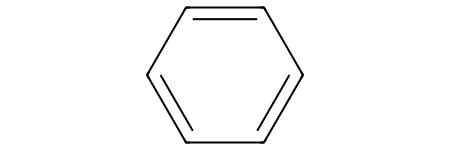

In [30]:
Chem.MolFromSmiles("C1=CC=CC=C1")

In [31]:
import pandas as pd
train = pd.read_csv("trainExtended1812.csv")

train.loc[train["SMILES"] == "C(CNC(=O)N)C(=O)O"]

,id,SMILES,Tm,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,...,Group 416,Group 417,Group 418,Group 419,Group 420,Group 421,Group 422,Group 423,Group 424,cid


In [32]:
train1 = pd.concat([train, df])

In [33]:
train1

,id,SMILES,Tm,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,...,Group 416,Group 417,Group 418,Group 419,Group 420,Group 421,Group 422,Group 423,Group 424,cid
0,2175.0,FC1=C(F)C(F)(F)C1(F)F,213.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,1222.0,c1ccc2c(c1)ccc3Nc4ccccc4c23,407.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,2994.0,CCN1C(C)=Nc2ccccc12,324.15,2.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,1704.0,CC#CC(=O)O,351.15,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,2526.0,CCCCC(S)C,126.15,2.0,3.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223,NaN,CN(C)CCC=C1C2=CC=CC=C2COC3=CC=CC=C31,458.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3158.0
224,NaN,CC(C1=CC=CC=C1)(C2=CC=CC=N2)OCCN(C)C,278.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3162.0
225,NaN,C1CN(CC=C1N2C3=CC=CC=C3NC2=O)CCCC(=O)C4=CC=C(C...,343.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3168.0
226,NaN,CCCCOC1=CC=C(C=C1)C(=O)CCN2CCCCC2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3180.0


In [34]:
# train1 = train1.drop(["id", "cid"], axis = 1)

train1.to_csv("trainExtended1812(2).csv", index=False)